# Clasificación con clases desbalanceadas y pesos

### ¿Qué es?

* En la vida real los fenómenos no ocurren con la misma frecuencia.
  - Hay eventos muy comunes (la mayoría de los casos).
  - Y hay eventos raros pero críticos (los que de verdad queremos detectar).
* `Esto genera datasets donde una clase es mucho más grande que la otra`.
* Un modelo que prediga siempre la clase mayoritaria tendría 95% de accuracy, pero sería inútil porque ignora lo que nos interesa.
* ***EJEMPLOS***
  - Bancos: 99.9% de transacciones son normales y 0.1% son fraudes.
  - Medicina: 95% de pacientes sanos y 5% con una enfermedad rara.
  - Seguridad informática: 99% de conexiones son legítimas. y 1% son ataques (phishing, intrusión, malware).

* `Si entrenamos un clasificador normal, la clase mayoritaria domina la función de pérdida.`
* `El modelo aprende a predecir casi siempre la clase mayoritaria → parece tener alta “accuracy”`, pero en realidad falla en lo más importante: ***la clase minoritaria***.
* Por eso surge la necesidad de ajustar pesos o usar otras técnicas (oversampling, SMOTE, undersampling, etc.).

### Datos de Cancer de Mama

* Estos datos son extraidos de la Universidad de Wisconsin, pero ligeramente alterados para ver este problema.
* Para estos datos, podemos ver como son 330 instancias las cuales se separan en 2 tipo de datos 0-Sano, 1-Cancer, el detalle es que tenemos 300 instacias de personas sanas y solo 30 de personas con cancer.
* Podemos ver como claramente la mayoría de los datos son personas sanas y solo un un 10% aproximadamente para que el modelo dectecte correctamente personas con cáncer.
* Como parte de agilizar esto, el modelo será entrenado con todos los datos, claramente esto puede crear un sobreajuste.

### Código para Gráficar Matriz de Confusión.

* La matriz de confusión no es solo para clasificación binaria. También se puede usar en problemas de clasificación multiclase.
* Es una tabla que se utiliza para evaluar el rendimiento de un modelo de clasificación, mostrando las predicciones correctas e incorrectas comparadas con los valores reales.
* En un problema binario (por ejemplo, positivo vs negativo), la matriz de confusión es de 2x2
  - Verdaderos Negativos
  - Falsos Negativos
  - Falsos Positivos
  - Verdaderos Positivos
* Para problemas con más de dos clases (por ejemplo, clase A, B, C), la matriz de confusión se convierte en una tabla NxN, donde N es el número de clases.

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score 


def matriz_de_confusion(clases_reales, clases_predichas, titulo):
    """ Visualiza la matriz de confusión """

    ### Instaciamos nuestra matriz de confunción
    matriz = confusion_matrix(clases_reales, clases_predichas)

    ### Calculamos el accuracy de nuestro modelo de regresión.
    accuracy = accuracy_score(clases_reales, clases_predichas)
    
    ### Código de matplotlib para graficar 
    plt.figure(figsize=(4, 4))

    ### Creamos nuestro dataframe con ambos datos.
    matriz = pd.DataFrame(matriz, 
                          columns=["0 : Sano", "1 : Cáncer"])
    
    plt.matshow(matriz, cmap="summer", vmin=0, vmax=20, fignum=1)
    plt.xticks(range(len(matriz.columns)), matriz.columns, rotation=45)
    plt.yticks(range(len(matriz.columns)), matriz.columns)
    etiquetas = (("Verdaderos\nnegativos", "Falsos\npositivos"),
                 ("Falsos\nnegativos", "Verdaderos\npositivos"))
    plt.text(1.60, -0.30, titulo, fontsize=25, c="red")
    plt.text(2.1, 0.10, "Accuracy: %0.2f" % accuracy, fontsize=20)
    for i in range(len(matriz.columns)):
        for j in range(len(matriz.columns)):
            plt.text(i, j + 0.14, str(matriz.iloc[i, j]),
                     fontsize=30, ha="center", va="center")
            plt.text(i, j - 0.25, etiquetas[i][j],
                     fontsize=11.5, ha="center", va="center")           
    plt.show()

### Datos de Cáncer de Mama

* El modelo busca el Minimización del Error de Clasificación.
* Lo que interesa es que detecte cancer, no sanas.

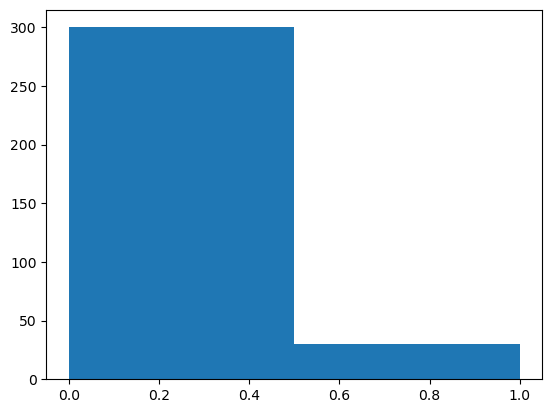

In [7]:
### Cargamos nuestros en un array de numpy
info = np.loadtxt("cancer.csv", delimiter=",", unpack=True)

### Cargamos las 30 características: radio, textura, area, entre otros
datos = info[:-1].T

### Cargamos los targets (0 : SANO, 1 : CÁNCER)
clase = info[-1]

### Creamos un histograma para ver la comparación de los datos
plt.hist(clase, bins=2)
plt.show()

### Evaluación del Modelo

* Para este contexto de estar buscando personas con cáncer, podemos decir que negativo son las personas que no tienen cancer, y positivos caso contrario.
* Con este ajuste, podemos ver como 295 fueron correctamente detectados como no con cancer, 10 fueron clasificados como no cancer pero si tenían, 5 fueron detectados con cancer pero no tenían y por ultimo solo 20 fueron clasificados con cancer correctamente.
* A simple vista pareciera que el modelo es muy bueno y el accuracy tiene un porcentaje elevado, pero esto no nos sirve, ya que lo que realmente nos interesa es que los Falsos Negativos tengan más peso a la hora de evaluar ya que es más peligroso decirle a una persona con cáncer que no tiene, a una que no tiene pero si lo marcaron con cancer.
* Ambos son errores, pero uno debería tener más criticidad que otro.
* Actualmente nuestro modelo está diciendo ***De 30 pacientes 20 fueron clasificados correctamente y 10 no fueron advertidos de que tenían cáncer***

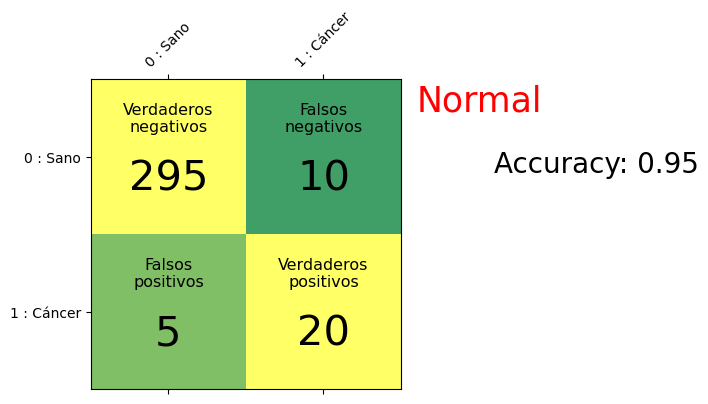

In [12]:
### Entrenamos nuestro modelo de clasificación
modelo = LogisticRegression().fit(datos, clase)

### Para pode sacar las metricas pasamos los datos reales y los datos que prediga.
matriz_de_confusion(clase, modelo.predict(datos), "Normal") 

* Para asignar este valor, mandamos a llamar a `class_weight`.
* Este recibe un simple diccionario, donde a cada clase le asignamos un valor.
* Con estos pesos, podemo ver como se penaliza más a los `Falsos Negativos`, pero podemos ver como ahora fueron diagnosticadas más personas sanas con cáncer.
* Inclusive todas las personas con cáncer fueron correctamente identificadas.

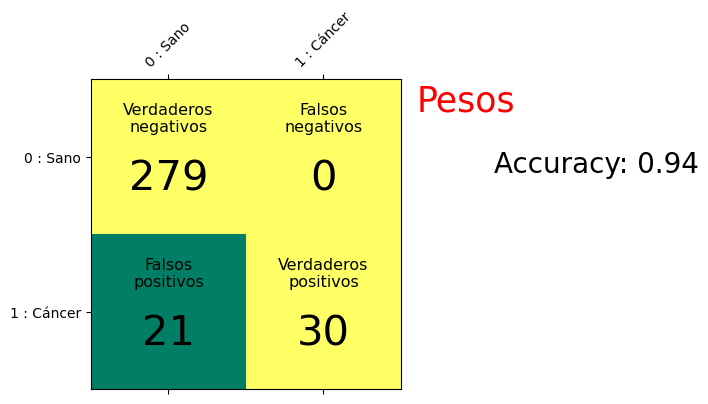

In [13]:
modelo = LogisticRegression(class_weight={0 : 1, 1 : 100}).fit(datos, clase)
matriz_de_confusion(clase, modelo.predict(datos), "Pesos")

* Si quieremos encontrar los mejores pesos, usamos la heurísitica `balanced`

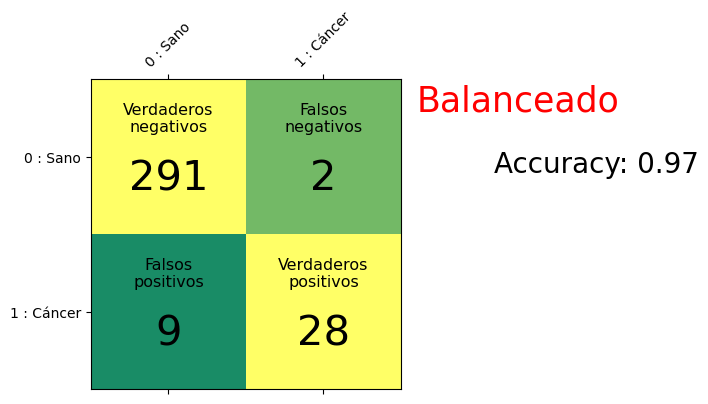

In [10]:
modelo = LogisticRegression(class_weight="balanced").fit(datos, clase)
matriz_de_confusion(clase, modelo.predict(datos), "Balanceado") 

* `[ 330 / (2 * 300)]`: Total de las muestras entre Total Clases * N Valores clase 0
* `[ 330 / (2 * 30) ]`: Total de las muestras entre Total Clases * N Valores clase 1

0.55 5.5


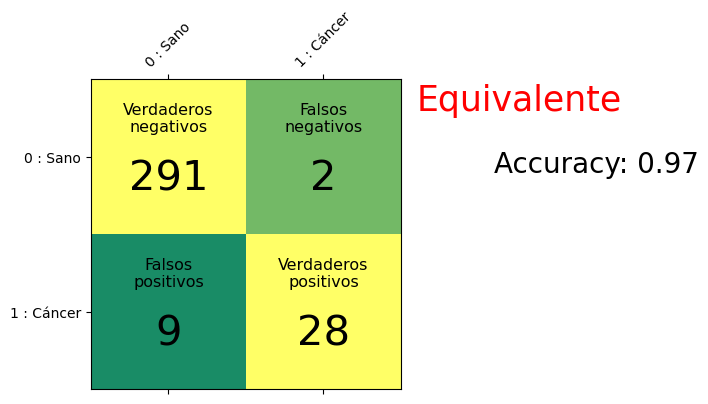

In [14]:
### Calculamos los pesos manualmente
print(330 / (2 * 300), 330 / (2 * 30)) 
modelo = LogisticRegression(class_weight={0 : 0.55, 1 : 5.5}).fit(datos, clase)
matriz_de_confusion(clase, modelo.predict(datos), "Equivalente") 